# ***Import Required Libraries***

In [8]:
import os
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

# ***Load and Organize the Dataset***

In [27]:
print("Class indices:", train_generator.class_indices)
print("Number of classes:", train_generator.num_classes)

Class indices: {'dark': 0, 'light': 1, 'lighten': 2, 'mid dark': 3, 'mid light': 4, 'mid-dark': 5, 'mid-light': 6}
Number of classes: 7


In [13]:
dataset_dir = '/kaggle/input/dataset-skin-tone/data_skintone/'

rename_map = {
    'lighten': 'light',
    'mid dark': 'mid-dark',
    'mid light': 'mid-light'
}

for wrong_name, correct_name in rename_map.items():
    wrong_path = os.path.join(dataset_dir, wrong_name)
    correct_path = os.path.join(dataset_dir, correct_name)
    
    
    if os.path.exists(wrong_path):
        os.rename(wrong_path, correct_path)

categories = ['dark', 'light', 'mid-dark', 'mid-light']

train_paths = []
val_paths = []
train_labels = []
val_labels = []

for category in categories:
    category_path = os.path.join(dataset_dir, category)
    for img_name in os.listdir(category_path):
        if img_name.endswith(('.png', '.jpg', '.jpeg')):
            train_paths.append(os.path.join(category_path, img_name))
            train_labels.append(category)

train_paths, val_paths, train_labels, val_labels = train_test_split(train_paths, train_labels, test_size=0.2, stratify=train_labels)

train_dir = '/kaggle/working/train'
valid_dir = '/kaggle/working/val'

for category in categories:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(valid_dir, category), exist_ok=True)

for img, label in zip(train_paths, train_labels):
    shutil.copy(img, os.path.join(train_dir, label, os.path.basename(img)))

for img, label in zip(val_paths, val_labels):
    shutil.copy(img, os.path.join(valid_dir, label, os.path.basename(img)))

print("Dataset has been successfully renamed and reorganized!")

Dataset has been successfully renamed and reorganized!


In [14]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    classes=categories  # Only 4 classes
)

validation_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    classes=categories  # Only 4 classes
)

print("Class indices after renaming:", train_generator.class_indices)

Found 34415 images belonging to 4 classes.
Found 12918 images belonging to 4 classes.
Class indices after renaming: {'dark': 0, 'light': 1, 'mid-dark': 2, 'mid-light': 3}


In [28]:
categories = ['dark', 'light', 'lighten', 'mid dark', 'mid light', 'mid-dark', 'mid-light']

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    classes=categories
)

validation_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    classes=categories
)

print(f"Class indices: {train_generator.class_indices}")

Found 35773 images belonging to 7 classes.
Found 21095 images belonging to 7 classes.
Class indices: {'dark': 0, 'light': 1, 'lighten': 2, 'mid dark': 3, 'mid light': 4, 'mid-dark': 5, 'mid-light': 6}


 # ***Data Augmentation and Preprocessing***

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 28663 images belonging to 7 classes.
Found 7166 images belonging to 7 classes.


# ***Model Creation Using Transfer Learning (MobileNetV2)***

In [10]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(len(categories), activation='softmax')(x)  # 4 classes (dark, light, mid-dark, mid-light)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,573,828 (13.63 MB)

 Trainable params: 1,315,844 (5.02 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
# base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# for layer in base_model.layers:
#     layer.trainable = False

# x = base_model.output
# x = GlobalAveragePooling2D()(x)
# x = Dense(1024, activation='relu')(x)

# predictions = Dense(7, activation='softmax')(x)

# model = Model(inputs=base_model.input, outputs=predictions)

# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#  ***Train the Model***

In [30]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)

Epoch 1/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 443s 394ms/step - accuracy: 0.8131 - loss: 0.4236 - val_accuracy: 0.8299 - val_loss: 0.3852
Epoch 2/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 446s 397ms/step - accuracy: 0.8154 - loss: 0.4111 - val_accuracy: 0.8403 - val_loss: 0.3679
Epoch 3/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 446s 396ms/step - accuracy: 0.8302 - loss: 0.3920 - val_accuracy: 0.8397 - val_loss: 0.3622
Epoch 4/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 447s 398ms/step - accuracy: 0.8327 - loss: 0.3870 - val_accuracy: 0.8437 - val_loss: 0.3498
Epoch 5/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 449s 399ms/step - accuracy: 0.8342 - loss: 0.3786 - val_accuracy: 0.8575 - val_loss: 0.3272
Epoch 6/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 446s 397ms/step - accuracy: 0.8352 - loss: 0.3711 - val_accuracy: 0.8551 - val_loss: 0.3241
Epoch 7/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 446s 397ms/step - accuracy: 0.8415 - loss: 0.3602 - val_accuracy: 0.8344 - val_loss: 0.3653
Epoch 8/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 445s 395ms/step - ac

# ***Visualize Training Performance***

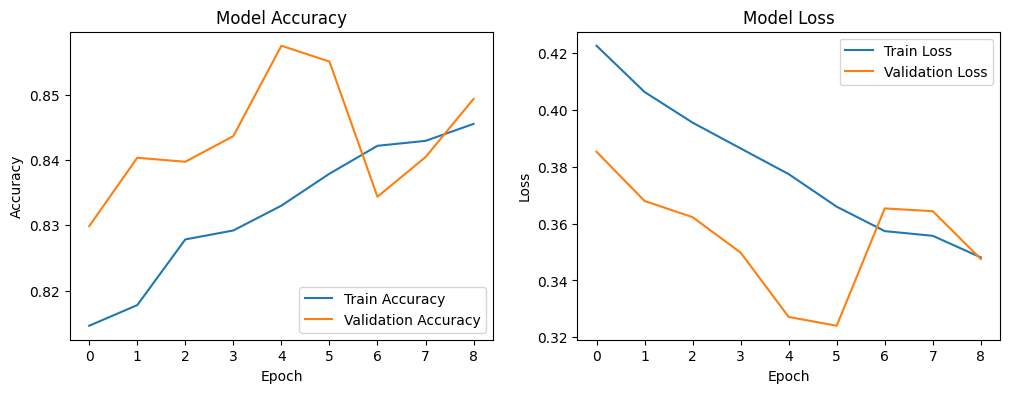

In [31]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

#  ***Evaluate the Model***

In [32]:
validation_loss, validation_accuracy = model.evaluate(validation_generator)
print(f"Validation Accuracy: {validation_accuracy * 100:.2f}%")

660/660 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - accuracy: 0.8572 - loss: 0.3258
Validation Accuracy: 85.51%


#  ***Confusion Matrix and Classification Report***

660/660 ━━━━━━━━━━━━━━━━━━━━ 47s 71ms/step
Unique predicted classes: [0 1 5 6]
Unique true classes: [0 1 5 6]


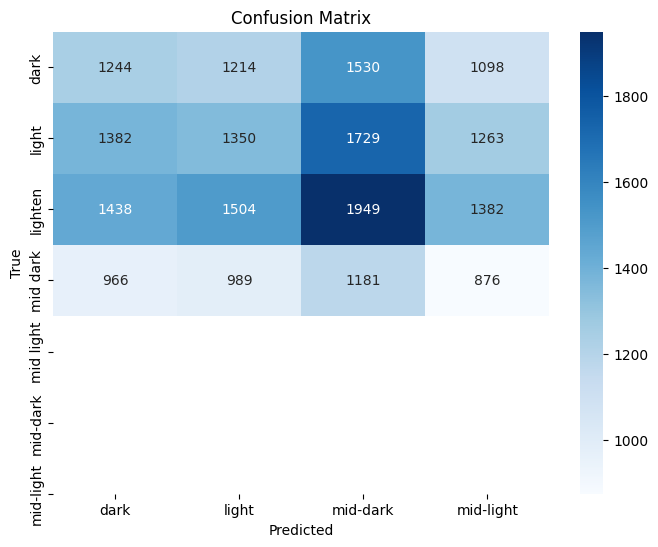

              precision    recall  f1-score   support

        dark       0.25      0.24      0.25      5086
       light       0.27      0.24      0.25      5724
    mid-dark       0.31      0.31      0.31      6273
   mid-light       0.19      0.22      0.20      4012

    accuracy                           0.26     21095
   macro avg       0.25      0.25      0.25     21095
weighted avg       0.26      0.26      0.26     21095



In [35]:
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

y_true = validation_generator.classes

unique_pred_classes = np.unique(y_pred)
unique_true_classes = np.unique(y_true)

print(f"Unique predicted classes: {unique_pred_classes}")
print(f"Unique true classes: {unique_true_classes}")

actual_categories = [categories[i] for i in unique_pred_classes]

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=actual_categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, labels=unique_pred_classes, target_names=actual_categories))

#  ***Save the Model***

In [36]:
model.save('/kaggle/working/skin_tone_model.h5')

#  ***Inference***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


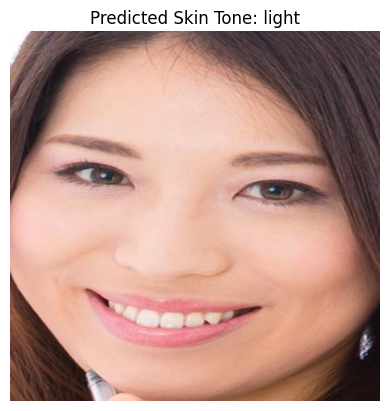

Predicted Skin Tone Class: light


In [39]:
img_path = '/kaggle/input/dataset-skin-tone/data_skintone/light/10015832.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

plt.imshow(image.load_img(img_path))
plt.title(f'Predicted Skin Tone: {categories[predicted_class]}')
plt.axis('off')
plt.show()

print(f'Predicted Skin Tone Class: {categories[predicted_class]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


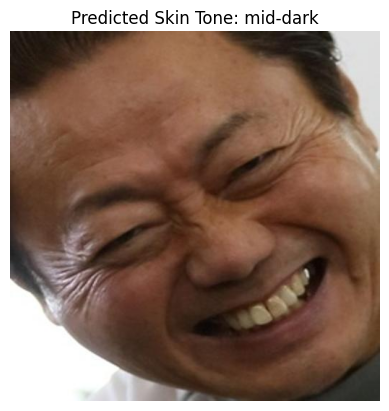

Predicted Skin Tone Class: mid-dark


In [43]:
img_path = '/kaggle/input/dataset-skin-tone/data_skintone/mid-dark/24284023.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

plt.imshow(image.load_img(img_path))
plt.title(f'Predicted Skin Tone: {categories[predicted_class]}')
plt.axis('off')
plt.show()

print(f'Predicted Skin Tone Class: {categories[predicted_class]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


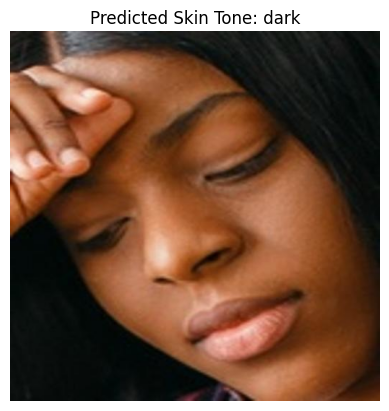

Predicted Skin Tone Class: dark


In [42]:
img_path = '/kaggle/input/dataset-skin-tone/data_skintone/dark/50072179.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

plt.imshow(image.load_img(img_path))
plt.title(f'Predicted Skin Tone: {categories[predicted_class]}')
plt.axis('off')
plt.show()

print(f'Predicted Skin Tone Class: {categories[predicted_class]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


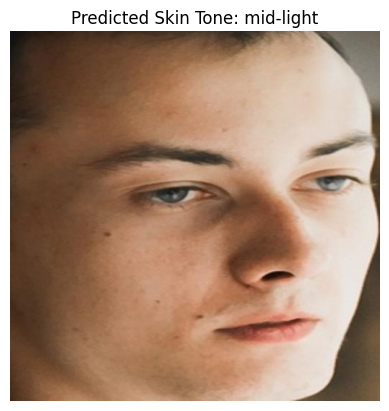

Predicted Skin Tone Class: mid-light


In [44]:
img_path = '/kaggle/input/dataset-skin-tone/data_skintone/mid-light/100013282.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

plt.imshow(image.load_img(img_path))
plt.title(f'Predicted Skin Tone: {categories[predicted_class]}')
plt.axis('off')
plt.show()

print(f'Predicted Skin Tone Class: {categories[predicted_class]}')

In [45]:
from tensorflow.keras.models import load_model
model = load_model('/kaggle/working/skin_tone_model.h5')